In [23]:
# Import NumPy for array handling in the notebook.
import numpy as np

In [24]:
# Load input and fluid data for OP1 to OP6.
from load_op_inputs import load_op_input_and_fluid

# Load the requested OP inputs and fluid values in one bundle.
op_data = load_op_input_and_fluid([1, 2, 3, 4, 5, 6])

In [25]:
# Split the loaded bundle into separate variables for each OP.
inputSignals1 = op_data[1]["input_signals"]
fv1 = op_data[1]["fluidstoffwerte"]

inputSignals2 = op_data[2]["input_signals"]
fv2 = op_data[2]["fluidstoffwerte"]

inputSignals3 = op_data[3]["input_signals"]
fv3 = op_data[3]["fluidstoffwerte"]

inputSignals4 = op_data[4]["input_signals"]
fv4 = op_data[4]["fluidstoffwerte"]

inputSignals5 = op_data[5]["input_signals"]
fv5 = op_data[5]["fluidstoffwerte"]

inputSignals6 = op_data[6]["input_signals"]
fv6 = op_data[6]["fluidstoffwerte"]

In [26]:
# Load FMU outputs for OP1 to OP7 and keep time arrays by OP ID.
from pathlib import Path
import csv

dataset_roots = [
    Path(r"c:\Users\M0245635\Downloads"),
    Path(r"c:\Users\M0245635\Desktop"),
]

def get_op_file(op_id: int, file_name: str) -> Path:
    checked = []
    for root in dataset_roots:
        nested = root / f"OP{op_id}" / f"OP{op_id}" / file_name
        flat = root / f"OP{op_id}" / file_name
        checked.extend([nested, flat])
        if nested.exists():
            return nested
        if flat.exists():
            return flat
    checked_str = "\n".join(str(p) for p in checked)
    raise FileNotFoundError(f"Could not find {file_name} for OP{op_id}. Checked:\n{checked_str}")

def load_csv_headers_and_data(file_path: Path) -> tuple[list[str], np.ndarray]:
    with file_path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        headers = next(reader)

    data = np.genfromtxt(file_path, delimiter=",", skip_header=1, dtype=float)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return headers, data

fmu_data = {}
for op_id in range(1, 8):
    fmu_file = get_op_file(op_id, f"OP{op_id}_Batemo FMU1.csv")
    headers, data = load_csv_headers_and_data(fmu_file)
    fmu_data[op_id] = {"headers": headers, "data": data}

T_by_op = {op_id: fmu_data[op_id]["data"][:, 0] for op_id in range(1, 8)}

# Convenience aliases kept for compatibility with later cells.
T1 = T_by_op[1]
T2 = T_by_op[2]
T3 = T_by_op[3]
T4 = T_by_op[4]
T5 = T_by_op[5]
T6 = T_by_op[6]
T7 = T_by_op[7]

In [28]:
# Build multi-output FMU matrices for OP1 to OP7.
TARGET_NAMES = ("q", "soc", "bc_v", "bc_ocv", "pe_v_loss")

def _find_column_index(headers: list[str], token: str) -> int:
    token = token.lower()
    for i, h in enumerate(headers):
        if token in h.lower():
            return i
    raise ValueError(f"Column token '{token}' not found. Headers: {headers}")

def _find_first_column_index(headers: list[str], tokens: list[str]) -> int:
    for token in tokens:
        try:
            return _find_column_index(headers, token)
        except ValueError:
            pass
    raise ValueError(f"None of the column tokens were found: {tokens}")

def build_target_matrix(op_id: int) -> np.ndarray:
    fmu_headers = fmu_data[op_id]["headers"]
    fmu_values = fmu_data[op_id]["data"]

    q_idx = _find_column_index(fmu_headers, "bc_q monitor")
    soc_idx = _find_column_index(fmu_headers, "bc_soc monitor")
    bc_v_idx = _find_column_index(fmu_headers, "bc_v monitor")
    bc_ocv_idx = _find_column_index(fmu_headers, "bc_ocv monitor")
    # Support both old and corrected monitor names for robustness.
    pe_v_loss_idx = _find_first_column_index(fmu_headers, ["pe_v_loss monitor", "pe_p_loss monitor"])

    q = fmu_values[:, q_idx]
    soc = fmu_values[:, soc_idx]
    bc_v = fmu_values[:, bc_v_idx]
    bc_ocv = fmu_values[:, bc_ocv_idx]
    pe_v_loss = fmu_values[:, pe_v_loss_idx]
    return np.column_stack((q, soc, bc_v, bc_ocv, pe_v_loss))

target_by_op = {op_id: build_target_matrix(op_id) for op_id in range(1, 8)}

# Convenience aliases for OP1..OP7 target matrices.
bc1 = target_by_op[1]
bc2 = target_by_op[2]
bc3 = target_by_op[3]
bc4 = target_by_op[4]
bc5 = target_by_op[5]
bc6 = target_by_op[6]
bc7 = target_by_op[7]

# Verify each OP has matching time and target lengths.
target_time_matches = np.array(
    [len(T_by_op[op_id]) == target_by_op[op_id].shape[0] for op_id in range(1, 8)],
    dtype=bool,
 )
target_time_matches

array([ True,  True,  True,  True,  True,  True,  True])

In [29]:
# Example: get OP1 multi-output targets at the nearest point to 10 s.
target_time = 10.0
idx_10 = np.argmin(np.abs(T1 - target_time))

t_10 = T1[idx_10]
q_10 = bc1[idx_10, TARGET_NAMES.index("q")]
soc_10 = bc1[idx_10, TARGET_NAMES.index("soc")]
v_10 = bc1[idx_10, TARGET_NAMES.index("bc_v")]
ocv_10 = bc1[idx_10, TARGET_NAMES.index("bc_ocv")]
v_loss_10 = bc1[idx_10, TARGET_NAMES.index("pe_v_loss")]

print(f"OP1 nearest time to {target_time} s: {t_10}")
print(f"OP1 q at {t_10} s: {q_10}")
print(f"OP1 soc at {t_10} s: {soc_10}")
print(f"OP1 bc_v at {t_10} s: {v_10}")
print(f"OP1 bc_ocv at {t_10} s: {ocv_10}")
print(f"OP1 pe_v_loss at {t_10} s: {v_loss_10}")

OP1 nearest time to 10.0 s: 9.99999999999998
OP1 q at 9.99999999999998 s: 61448.49178275082
OP1 soc at 9.99999999999998 s: 10.525013180666273
OP1 bc_v at 9.99999999999998 s: 3.6935894468642196
OP1 bc_ocv at 9.99999999999998 s: 3.483680644148867
OP1 pe_v_loss at 9.99999999999998 s: 57.90073205152309


In [30]:
# Header: fast OP sampler with efficient random multi-sample support.
from typing import Dict

# Explicit split: train on OP1..OP6, hold out OP7 for test only.
TRAIN_OP_IDS = (1, 2, 3, 4, 5, 6)
TEST_OP_ID = 7
print(f"Training split: OPs {TRAIN_OP_IDS} | Holdout test OP: {TEST_OP_ID}")

# Build OP-indexed dictionaries from existing notebook variables.
t_by_op = {op_id: T_by_op[op_id] for op_id in TRAIN_OP_IDS}
bc_by_op = {op_id: target_by_op[op_id] for op_id in TRAIN_OP_IDS}
input_signals_by_op = {
    1: inputSignals1,
    2: inputSignals2,
    3: inputSignals3,
    4: inputSignals4,
    5: inputSignals5,
    6: inputSignals6,
}
fluid_values_by_op = {
    1: fv1,
    2: fv2,
    3: fv3,
    4: fv4,
    5: fv5,
    6: fv6,
}

# Use the original CSV column labels where available.
input_headers_by_op = {op_id: [h.strip() for h in op_data[op_id]["input_headers"]] for op_id in TRAIN_OP_IDS}
fluid_headers_by_op = {op_id: [h.strip() for h in op_data[op_id]["fluid_headers"]] for op_id in TRAIN_OP_IDS}

def build_fast_sampler(
    t_by_op: Dict[int, np.ndarray],
    bc_by_op: Dict[int, np.ndarray],
    input_signals_by_op: Dict[int, np.ndarray],
    fluid_values_by_op: Dict[int, np.ndarray],
    input_headers_by_op: Dict[int, list[str]],
    fluid_headers_by_op: Dict[int, list[str]],
    target_names: tuple[str, ...],
):
    """
    Prepare and return an efficient sampling callable.

    Output order per sample:
    [op_id, time, inputs..., fluid values..., targets...]
    """
    ops = sorted(t_by_op.keys())
    ops_arr = np.asarray(ops, dtype=int)
    rng = np.random.default_rng()

    cache = {}
    expected_n_cols = None
    canonical_headers = None

    for op_id in ops:
        t_vec = np.asarray(t_by_op[op_id], dtype=float).reshape(-1)
        if t_vec.size == 0:
            raise ValueError(f"T list for OP{op_id} is empty")

        bc_mat = np.asarray(bc_by_op[op_id], dtype=float)
        if bc_mat.ndim != 2 or bc_mat.shape[1] < len(target_names):
            raise ValueError(f"bc_by_op[{op_id}] must have at least {len(target_names)} target columns")
        if bc_mat.shape[0] != t_vec.size:
            raise ValueError(f"Length mismatch for OP{op_id}: len(t)={t_vec.size}, bc rows={bc_mat.shape[0]}")

        input_vals = np.asarray(input_signals_by_op[op_id], dtype=float).reshape(-1)
        fv_vals = np.asarray(fluid_values_by_op[op_id], dtype=float).reshape(-1)
        static_vals = np.concatenate([input_vals, fv_vals])

        in_headers = input_headers_by_op.get(op_id, [])
        fv_headers = fluid_headers_by_op.get(op_id, [])

        if len(in_headers) != input_vals.size:
            in_headers = [f"input_{i + 1}" for i in range(input_vals.size)]
        if len(fv_headers) != fv_vals.size:
            fv_headers = [f"fv_{i + 1}" for i in range(fv_vals.size)]

        headers = ["op_id", "time"] + in_headers + fv_headers + list(target_names)

        if expected_n_cols is None:
            expected_n_cols = len(headers)
            canonical_headers = headers
        elif len(headers) != expected_n_cols:
            raise ValueError(
                f"Feature count mismatch. OP{op_id} has {len(headers)} columns, expected {expected_n_cols}."
            )

        cache[op_id] = {
            "t_vec": t_vec,
            "t_min": float(np.min(t_vec)),
            "t_max": float(np.max(t_vec)),
            "bc_mat": bc_mat[:, :len(target_names)],
            "static_vals": static_vals,
        }

    static_start = 2
    static_end = expected_n_cols - len(target_names)

    def sample(n_samples: int = 1) -> np.ndarray:
        n_samples = int(n_samples)
        if n_samples < 1:
            raise ValueError("n_samples must be >= 1")

        op_ids = rng.choice(ops_arr, size=n_samples, replace=True)

        rows = np.empty((n_samples, expected_n_cols), dtype=object)
        rows[:, 0] = op_ids

        for op_id in ops:
            mask = op_ids == op_id
            if not np.any(mask):
                continue

            c = cache[op_id]
            m = int(np.sum(mask))
            sampled_times = rng.uniform(c["t_min"], c["t_max"], size=m)
            t_vec = c["t_vec"]

            if t_vec.size == 1:
                idx = np.zeros(m, dtype=int)
            else:
                pos = np.searchsorted(t_vec, sampled_times, side="left")
                pos = np.clip(pos, 1, t_vec.size - 1)
                left = pos - 1
                right = pos
                choose_right = np.abs(t_vec[right] - sampled_times) < np.abs(t_vec[left] - sampled_times)
                idx = np.where(choose_right, right, left)

            row_idx = np.flatnonzero(mask)
            rows[row_idx, 1] = t_vec[idx]
            rows[row_idx, static_start:static_end] = c["static_vals"]
            rows[row_idx, static_end:] = c["bc_mat"][idx, :]

        if n_samples == 1:
            return np.array([canonical_headers, rows[0]], dtype=object)

        return np.vstack([
            np.asarray(canonical_headers, dtype=object),
            rows,
        ])

    return sample

# Build sampler once, then reuse for fast repeated calls.
sample = build_fast_sampler(
    t_by_op=t_by_op,
    bc_by_op=bc_by_op,
    input_signals_by_op=input_signals_by_op,
    fluid_values_by_op=fluid_values_by_op,
    input_headers_by_op=input_headers_by_op,
    fluid_headers_by_op=fluid_headers_by_op,
    target_names=TARGET_NAMES,
 )

# Keep result in one variable.
result = sample(2)
print(result)

Training split: OPs (1, 2, 3, 4, 5, 6) | Holdout test OP: 7
[['op_id' 'time' 'C-Rate Monitor (1/h)' 'Cell Current Monitor (A)'
  'Fluid Initial Temperature Monitor (C)'
  'Fluid Inlet Temperature Monitor (C)' 'Fluid Mass Flow Monitor (kg/s)'
  'SOC Start Monitor (%)' 'Solid Initial Temperature Monitor (C)'
  'Conductivity Monitor (W/m-K)' 'Density Monitor (kg/m^3)'
  'Specific Inlet Monitor (J/kg-K)' 'q' 'soc' 'bc_v' 'bc_ocv' 'pe_v_loss']
 [2 1117.600000000079 2.0 316.0 15.0 15.0 0.0013 10.0 15.0
  0.394949669349472 1077.32774797359 3325.45290887157 411767.3666557056
  70.14705459026436 4.151902525295663 3.9925437826158054
  65.24019428336854]
 [1 1149.7000000000498 2.0 316.0 25.0 25.0 0.0013 10.0 25.0
  0.400127322695396 1071.63575819849 3374.085596661 421593.6655422776
  72.21135552693039 4.166203958294981 4.019929196925231 60.38377199731654]]


In [31]:
# PINN setup: multi-output normalized training + balanced data/physics losses.
# Eq3 (solid-fluid coupling) and Eq6 (energy conservation) are intentionally ignored in this training loss.
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Sequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class BatteryPINN(nn.Module):
    """PINN with tanh hidden layers and a linear multi-output head."""

    def __init__(self, input_dim: int, hidden_layers: Sequence[int], output_dim: int):
        super().__init__()
        if len(hidden_layers) == 0:
            raise ValueError("hidden_layers must contain at least one layer width")

        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.append(nn.Linear(prev, int(width)))
            layers.append(nn.Tanh())
            prev = int(width)

        layers.append(nn.Linear(prev, int(output_dim)))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

def _safe_std(v: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    s = np.std(v, axis=0, ddof=0)
    return np.where(s < eps, 1.0, s)

def _infer_current_header_index(headers: list[str]) -> int:
    for i, h in enumerate(headers):
        h_low = h.lower()
        if "current" in h_low or "strom" in h_low:
            return i
    raise ValueError(
        "Could not infer current column from headers. "
        "Set current_feature_name or current_feature_index in the training cell."
    )

def _finite_row_mask(values: np.ndarray) -> np.ndarray:
    return np.isfinite(values).all(axis=1)

def _apply_feature_target_clipping(
    x_np: np.ndarray,
    y_np: np.ndarray,
    x_low: np.ndarray,
    x_high: np.ndarray,
    y_low: np.ndarray,
    y_high: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    x_np = np.clip(x_np, x_low, x_high)
    y_np = np.clip(y_np, y_low, y_high)
    return x_np, y_np

def build_dataset_scaler(
    sample_fn,
    target_names: tuple[str, ...],
    n_stats_samples: int = 50000,
    current_feature_name: Optional[str] = None,
    current_feature_index: Optional[int] = None,
    clip_percentiles: tuple[float, float] = (0.5, 99.5),
):
    """Estimate feature/target normalization statistics from random samples."""
    sampled = sample_fn(int(n_stats_samples))
    headers = [str(h) for h in sampled[0].tolist()]
    values = np.asarray(sampled[1:], dtype=float)

    finite_mask = _finite_row_mask(values)
    if not np.any(finite_mask):
        raise ValueError("No finite rows found while building scaler.")
    values = values[finite_mask]

    target_names = tuple(target_names)
    target_cols = [headers.index(name) for name in target_names]
    feature_cols = [i for i, h in enumerate(headers) if h not in {"op_id", *target_names}]
    time_idx = headers.index("time")

    if current_feature_index is not None:
        current_idx_in_headers = int(current_feature_index)
    elif current_feature_name is not None:
        current_idx_in_headers = headers.index(current_feature_name)
    else:
        current_idx_in_headers = _infer_current_header_index(headers)

    if current_idx_in_headers not in feature_cols:
        raise ValueError("Current column must be part of model inputs (time/input/fluid columns).")

    time_pos_in_x = feature_cols.index(time_idx)
    current_pos_in_x = feature_cols.index(current_idx_in_headers)

    x_np = values[:, feature_cols]
    y_np = values[:, target_cols]

    low_p, high_p = clip_percentiles
    x_low = np.percentile(x_np, low_p, axis=0)
    x_high = np.percentile(x_np, high_p, axis=0)
    y_low = np.percentile(y_np, low_p, axis=0)
    y_high = np.percentile(y_np, high_p, axis=0)

    x_np, y_np = _apply_feature_target_clipping(x_np, y_np, x_low, x_high, y_low, y_high)

    x_mean = np.mean(x_np, axis=0)
    x_std = _safe_std(x_np)
    y_mean = np.mean(y_np, axis=0)
    y_std = _safe_std(y_np)

    scaler = {
        "headers": headers,
        "target_names": target_names,
        "target_cols": target_cols,
        "target_pos": {name: i for i, name in enumerate(target_names)},
        "feature_cols": feature_cols,
        "time_pos_in_x": time_pos_in_x,
        "current_pos_in_x": current_pos_in_x,
        "x_low": x_low.astype(np.float32),
        "x_high": x_high.astype(np.float32),
        "y_low": y_low.astype(np.float32),
        "y_high": y_high.astype(np.float32),
        "x_mean": x_mean.astype(np.float32),
        "x_std": x_std.astype(np.float32),
        "y_mean": y_mean.astype(np.float32),
        "y_std": y_std.astype(np.float32),
    }
    return scaler

def build_training_batch(
    sample_fn,
    n_samples: int,
    scaler: dict,
    device: torch.device = device,
    norm_clip: float = 6.0,
):
    """Build one normalized random training batch from sample(n_samples)."""
    sampled = sample_fn(n_samples)
    values = np.asarray(sampled[1:], dtype=float)

    finite_mask = _finite_row_mask(values)
    if not np.any(finite_mask):
        raise ValueError("No finite rows found in sampled batch.")
    values = values[finite_mask]

    feature_cols = scaler["feature_cols"]
    x_np = values[:, feature_cols]
    y_np = values[:, scaler["target_cols"]]

    x_np, y_np = _apply_feature_target_clipping(
        x_np=x_np,
        y_np=y_np,
        x_low=scaler["x_low"],
        x_high=scaler["x_high"],
        y_low=scaler["y_low"],
        y_high=scaler["y_high"],
    )

    x_np = (x_np - scaler["x_mean"]) / scaler["x_std"]
    y_np = (y_np - scaler["y_mean"]) / scaler["y_std"]

    x_np = np.clip(x_np, -norm_clip, norm_clip)
    y_np = np.clip(y_np, -norm_clip, norm_clip)

    x = torch.tensor(x_np, dtype=torch.float32, device=device, requires_grad=True)
    y = torch.tensor(y_np, dtype=torch.float32, device=device)
    return x, y

def _denorm_y(y_norm: torch.Tensor, scaler: dict) -> torch.Tensor:
    y_mean = torch.tensor(scaler["y_mean"], dtype=torch.float32, device=y_norm.device).unsqueeze(0)
    y_std = torch.tensor(scaler["y_std"], dtype=torch.float32, device=y_norm.device).unsqueeze(0)
    return y_norm * y_std + y_mean

def compute_pinn_losses(
    model: nn.Module,
    x_norm: torch.Tensor,
    y_true_norm: torch.Tensor,
    scaler: dict,
    lambda_physics: float = 1.0,
    lambda_soc_physics: float = 1.0,
    lambda_power_physics: float = 1.0,
    output_weights: Optional[dict[str, float]] = None,
    coulomb_efficiency: float = 1.0,
    current_sign: float = 1.0,
):
    """
    Total loss = weighted data loss + weighted physics loss.

    Physics residuals used:
    1) SOC dynamics: dSOC/dt + sign * eta * I / Q = 0
    2) Electrical consistency: pe_v_loss - I * (bc_v - bc_ocv) = 0

    Eq3 and Eq6 are intentionally excluded from the physics loss.
    """
    target_names = scaler["target_names"]
    target_pos = scaler["target_pos"]

    y_pred_norm = model(x_norm)
    if y_pred_norm.shape[1] != len(target_names):
        raise ValueError(
            f"Model output_dim={y_pred_norm.shape[1]} but scaler expects {len(target_names)} targets."
        )

    if output_weights is None:
        output_weights = {name: 1.0 for name in target_names}
    else:
        output_weights = {name: float(output_weights.get(name, 1.0)) for name in target_names}

    per_target_data = {}
    data_loss = torch.tensor(0.0, device=x_norm.device)
    for name in target_names:
        i = target_pos[name]
        loss_i = F.mse_loss(y_pred_norm[:, i:i + 1], y_true_norm[:, i:i + 1])
        per_target_data[name] = loss_i
        data_loss = data_loss + output_weights[name] * loss_i

    y_pred_phys = _denorm_y(y_pred_norm, scaler)
    q_pred_phys = torch.clamp(y_pred_phys[:, target_pos["q"]:target_pos["q"] + 1], min=1e-6)
    soc_pred_norm = y_pred_norm[:, target_pos["soc"]:target_pos["soc"] + 1]

    grad_soc_wrt_x = torch.autograd.grad(
        outputs=soc_pred_norm,
        inputs=x_norm,
        grad_outputs=torch.ones_like(soc_pred_norm),
        create_graph=True,
        retain_graph=True,
    )[0]

    time_pos = scaler["time_pos_in_x"]
    current_pos = scaler["current_pos_in_x"]
    x_std_t = float(scaler["x_std"][time_pos])
    x_std_i = float(scaler["x_std"][current_pos])
    x_mean_i = float(scaler["x_mean"][current_pos])

    soc_idx = target_pos["soc"]
    soc_mean = float(scaler["y_mean"][soc_idx])
    soc_std = float(scaler["y_std"][soc_idx])
    soc_is_percent = abs(soc_mean) > 2.0
    soc_factor = 0.01 if soc_is_percent else 1.0

    dsoc_norm_dt_norm = grad_soc_wrt_x[:, time_pos:time_pos + 1]
    dsoc_dt_phys = dsoc_norm_dt_norm * (soc_std / x_std_t) * soc_factor

    current_norm = x_norm[:, current_pos:current_pos + 1]
    current_phys = current_norm * x_std_i + x_mean_i

    residual_soc = dsoc_dt_phys + current_sign * coulomb_efficiency * (current_phys / q_pred_phys)
    soc_physics_loss = F.mse_loss(residual_soc, torch.zeros_like(residual_soc))

    v_pred_phys = y_pred_phys[:, target_pos["bc_v"]:target_pos["bc_v"] + 1]
    ocv_pred_phys = y_pred_phys[:, target_pos["bc_ocv"]:target_pos["bc_ocv"] + 1]
    v_loss_pred_phys = y_pred_phys[:, target_pos["pe_v_loss"]:target_pos["pe_v_loss"] + 1]
    v_loss_rhs = current_phys * (v_pred_phys - ocv_pred_phys)
    power_physics_loss = F.mse_loss(v_loss_pred_phys, v_loss_rhs)

    physics_loss = lambda_soc_physics * soc_physics_loss + lambda_power_physics * power_physics_loss
    total_loss = data_loss + lambda_physics * physics_loss

    physics_terms = {
        "soc": soc_physics_loss,
        "power": power_physics_loss,
    }
    return total_loss, data_loss, physics_loss, per_target_data, physics_terms

def train_pinn(
    model: nn.Module,
    sample_fn,
    scaler: dict,
    optimizer: torch.optim.Optimizer,
    n_train: int,
    epochs: int,
    lambda_physics: float = 1.0,
    lambda_soc_physics: float = 1.0,
    lambda_power_physics: float = 1.0,
    output_weights: Optional[dict[str, float]] = None,
    coulomb_efficiency: float = 1.0,
    current_sign: float = 1.0,
    grad_clip_norm: float = 1.0,
    print_every: int = 100,
):
    target_names = scaler["target_names"]
    history = {
        "total": [],
        "data": [],
        "physics": [],
        "physics_soc": [],
        "physics_power": [],
        "data_by_target": {name: [] for name in target_names},
    }

    for epoch in range(1, epochs + 1):
        x_batch, y_batch = build_training_batch(
            sample_fn=sample_fn,
            n_samples=n_train,
            scaler=scaler,
            device=device,
        )

        optimizer.zero_grad(set_to_none=True)

        total_loss, data_loss, physics_loss, data_terms, physics_terms = compute_pinn_losses(
            model=model,
            x_norm=x_batch,
            y_true_norm=y_batch,
            scaler=scaler,
            lambda_physics=lambda_physics,
            lambda_soc_physics=lambda_soc_physics,
            lambda_power_physics=lambda_power_physics,
            output_weights=output_weights,
            coulomb_efficiency=coulomb_efficiency,
            current_sign=current_sign,
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
        optimizer.step()

        history["total"].append(float(total_loss.item()))
        history["data"].append(float(data_loss.item()))
        history["physics"].append(float(physics_loss.item()))
        history["physics_soc"].append(float(physics_terms["soc"].item()))
        history["physics_power"].append(float(physics_terms["power"].item()))
        for name in target_names:
            history["data_by_target"][name].append(float(data_terms[name].item()))

        if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
            progress_pct = 100.0 * epoch / epochs
            target_msg = " | ".join(
                f"{name}={data_terms[name].item():.3e}" for name in target_names
            )
            print(
                f"Epoch {epoch:5d}/{epochs} ({progress_pct:6.2f}%) | "
                f"total={total_loss.item():.6e} | "
                f"data={data_loss.item():.6e} | "
                f"physics={physics_loss.item():.6e} | "
                f"phys_soc={physics_terms['soc'].item():.3e} | "
                f"phys_power={physics_terms['power'].item():.3e} | "
                f"{target_msg}"
            )

    return history

Using device: cpu


## PINN Training Documentation (Updated)

### Split policy
- Training is fixed to OP1..OP6.
- OP7 is always holdout test only.

### Physics equations used
- Eq5 (SOC dynamics) is used.
- Eq4-style electrical consistency is used: `pe_v_loss - I * (bc_v - bc_ocv) = 0`.
- Eq3 and Eq6 are intentionally ignored.

### Data preprocessing (for better stability/results)
- Drop rows with non-finite values (`NaN`/`Inf`).
- Percentile clipping on train data (`0.5%` to `99.5%`) for features and targets.
- Reuse same clipping bounds in training batches and OP7 inference.
- Clip normalized values to `[-6, 6]`.

### OP7 bc_v plot
- OP7 evaluation now includes a `bc_v true vs pred` line plot sampled at every second (`1 s` spacing).

In [32]:
# Train cell: architecture + normalization-aware multi-output training run.
# Split policy: always TRAIN on OP1..OP6, hold out OP7 for testing.
print(f"Training split check -> TRAIN_OP_IDS={TRAIN_OP_IDS}, TEST_OP_ID={TEST_OP_ID}")

# Explicitly ignore Eq3 and Eq6 in the physics loss.
use_eq3 = False
use_eq6 = False
print(f"Physics equations active: Eq3={use_eq3}, Eq6={use_eq6} (both must stay False)")

hidden_layers = [128, 128, 128]

# Variable number of random training points sampled each epoch
n_train = 1000

# Training hyperparameters
epochs = 800
learning_rate = 5e-4

# Global physics scaling and per-equation scaling
lambda_physics = 1.0
lambda_soc_physics = 1.0
lambda_power_physics = 1.0

# Optional per-target data weights (bc_v emphasized for better bc_v accuracy).
output_weights = {
    "q": 1.0,
    "soc": 1.0,
    "bc_v": 2.5,
    "bc_ocv": 1.0,
    "pe_v_loss": 1.0,
}

coulomb_efficiency = 1.0
current_sign = 1.0  # set to -1.0 if your current sign convention is opposite
grad_clip_norm = 1.0
print_every = 20

# Optional: set one of these if automatic current-column detection is not correct
current_feature_name = None
current_feature_index = None

# Build normalization statistics once from random samples
scaler = build_dataset_scaler(
    sample_fn=sample,
    target_names=TARGET_NAMES,
    n_stats_samples=50000,
    current_feature_name=current_feature_name,
    current_feature_index=current_feature_index,
    clip_percentiles=(0.5, 99.5),
)
input_dim = len(scaler["feature_cols"])
output_dim = len(scaler["target_names"])

model = BatteryPINN(input_dim=input_dim, hidden_layers=hidden_layers, output_dim=output_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = train_pinn(
    model=model,
    sample_fn=sample,
    scaler=scaler,
    optimizer=optimizer,
    n_train=n_train,
    epochs=epochs,
    lambda_physics=lambda_physics,
    lambda_soc_physics=lambda_soc_physics,
    lambda_power_physics=lambda_power_physics,
    output_weights=output_weights,
    coulomb_efficiency=coulomb_efficiency,
    current_sign=current_sign,
    grad_clip_norm=grad_clip_norm,
    print_every=print_every,
)

print("Training finished.")

Training split check -> TRAIN_OP_IDS=(1, 2, 3, 4, 5, 6), TEST_OP_ID=7
Physics equations active: Eq3=False, Eq6=False (both must stay False)
Epoch     1/800 (  0.12%) | total=1.093557e+02 | data=6.254669e+00 | physics=1.031011e+02 | phys_soc=1.233e-06 | phys_power=1.031e+02 | q=9.689e-01 | soc=9.800e-01 | bc_v=9.262e-01 | bc_ocv=1.015e+00 | pe_v_loss=9.752e-01
Epoch    20/800 (  2.50%) | total=6.818504e+00 | data=5.647679e+00 | physics=1.170825e+00 | phys_soc=1.306e-06 | phys_power=1.171e+00 | q=8.501e-01 | soc=8.536e-01 | bc_v=8.785e-01 | bc_ocv=8.819e-01 | pe_v_loss=8.658e-01
Epoch    40/800 (  5.00%) | total=5.039073e+00 | data=4.642093e+00 | physics=3.969808e-01 | phys_soc=1.469e-06 | phys_power=3.970e-01 | q=6.859e-01 | soc=6.673e-01 | bc_v=7.005e-01 | bc_ocv=6.982e-01 | pe_v_loss=8.395e-01
Epoch    60/800 (  7.50%) | total=3.885617e+00 | data=3.390070e+00 | physics=4.955468e-01 | phys_soc=1.787e-06 | phys_power=4.955e-01 | q=4.720e-01 | soc=4.184e-01 | bc_v=5.107e-01 | bc_ocv=5.21

In [33]:
# Evaluation cell: compare real vs predicted multi-output targets in physical units.
n_eval = 20

sampled_eval = sample(n_eval)
headers_eval = [str(h) for h in sampled_eval[0].tolist()]
values_eval = np.asarray(sampled_eval[1:], dtype=float)

target_names = scaler["target_names"]
target_pos = scaler["target_pos"]
feature_cols = scaler["feature_cols"]

x_eval_np = values_eval[:, feature_cols]
y_true_np = values_eval[:, scaler["target_cols"]]

# Normalize eval features using training scaler
x_eval_np_norm = (x_eval_np - scaler["x_mean"]) / scaler["x_std"]

x_eval = torch.tensor(x_eval_np_norm, dtype=torch.float32, device=device)
model.eval()
with torch.no_grad():
    y_pred_norm = model(x_eval)
    y_pred = _denorm_y(y_pred_norm, scaler).detach().cpu().numpy()

print(f"Showing {n_eval} random training-style samples for targets: {target_names}")

# Compact table for key outputs including bc_v.
print(" idx |      q_true |      q_pred |    soc_true |    soc_pred |   bc_v_true |   bc_v_pred")
print("-----+-------------+-------------+-------------+-------------+-------------+-------------")
for i in range(n_eval):
    q_t = y_true_np[i, target_pos["q"]]
    q_p = y_pred[i, target_pos["q"]]
    soc_t = y_true_np[i, target_pos["soc"]]
    soc_p = y_pred[i, target_pos["soc"]]
    v_t = y_true_np[i, target_pos["bc_v"]]
    v_p = y_pred[i, target_pos["bc_v"]]
    print(
        f"{i:4d} | {q_t:11.4f} | {q_p:11.4f} | "
        f"{soc_t:11.4f} | {soc_p:11.4f} | {v_t:11.4f} | {v_p:11.4f}"
    )

print("\nPer-target metrics:")
for name in target_names:
    i = target_pos[name]
    true_i = y_true_np[:, i]
    pred_i = y_pred[:, i]
    mae_i = float(np.mean(np.abs(pred_i - true_i)))
    mape_i = float(np.mean(np.abs((pred_i - true_i) / np.maximum(np.abs(true_i), 1e-6))) * 100.0)
    print(f"{name:10s} | MAE={mae_i:.6f} | MAPE={mape_i:.3f}%")

Showing 20 random training-style samples for targets: ('q', 'soc', 'bc_v', 'bc_ocv', 'pe_v_loss')
 idx |      q_true |      q_pred |    soc_true |    soc_pred |   bc_v_true |   bc_v_pred
-----+-------------+-------------+-------------+-------------+-------------+-------------
   0 | 122657.6875 | 124673.0312 |     21.0090 |     21.4749 |      3.7991 |      3.7749
   1 | 334883.2721 | 332446.1562 |     57.3594 |     56.7622 |      4.0000 |      4.0317
   2 | 237239.2793 | 222977.7812 |     40.6348 |     38.0178 |      3.8720 |      3.8738
   3 | 285556.9762 | 277509.8125 |     48.6464 |     47.3811 |      3.9343 |      3.9654
   4 | 319746.8735 | 315466.8438 |     54.7668 |     53.6998 |      3.9541 |      3.9740
   5 | 134761.7871 | 146679.1875 |     22.9575 |     25.4192 |      3.8576 |      3.8151
   6 | 157480.8851 | 146706.1719 |     26.9736 |     25.1980 |      3.8124 |      3.7879
   7 | 512601.6583 | 503911.5625 |     87.7994 |     86.7922 |      4.3462 |      4.2932
   8 | 3187

Verification sample count: 256
Overall q   MAE : 9540.653190
Overall q   RMSE: 11863.135368
Overall soc MAE : 1.748448
Overall soc RMSE: 2.164085

Per-OP MAE summary:
 OP |      q_mae |    soc_mae | count
----+------------+------------+------
  1 | 11325.301048 |   1.970857 |    40
  2 | 8314.758315 |   1.488898 |    49
  3 | 11511.538640 |   2.120396 |    43
  4 | 8802.179415 |   1.642392 |    46
  5 | 9412.504630 |   1.852302 |    41
  6 | 8004.403049 |   1.436240 |    37


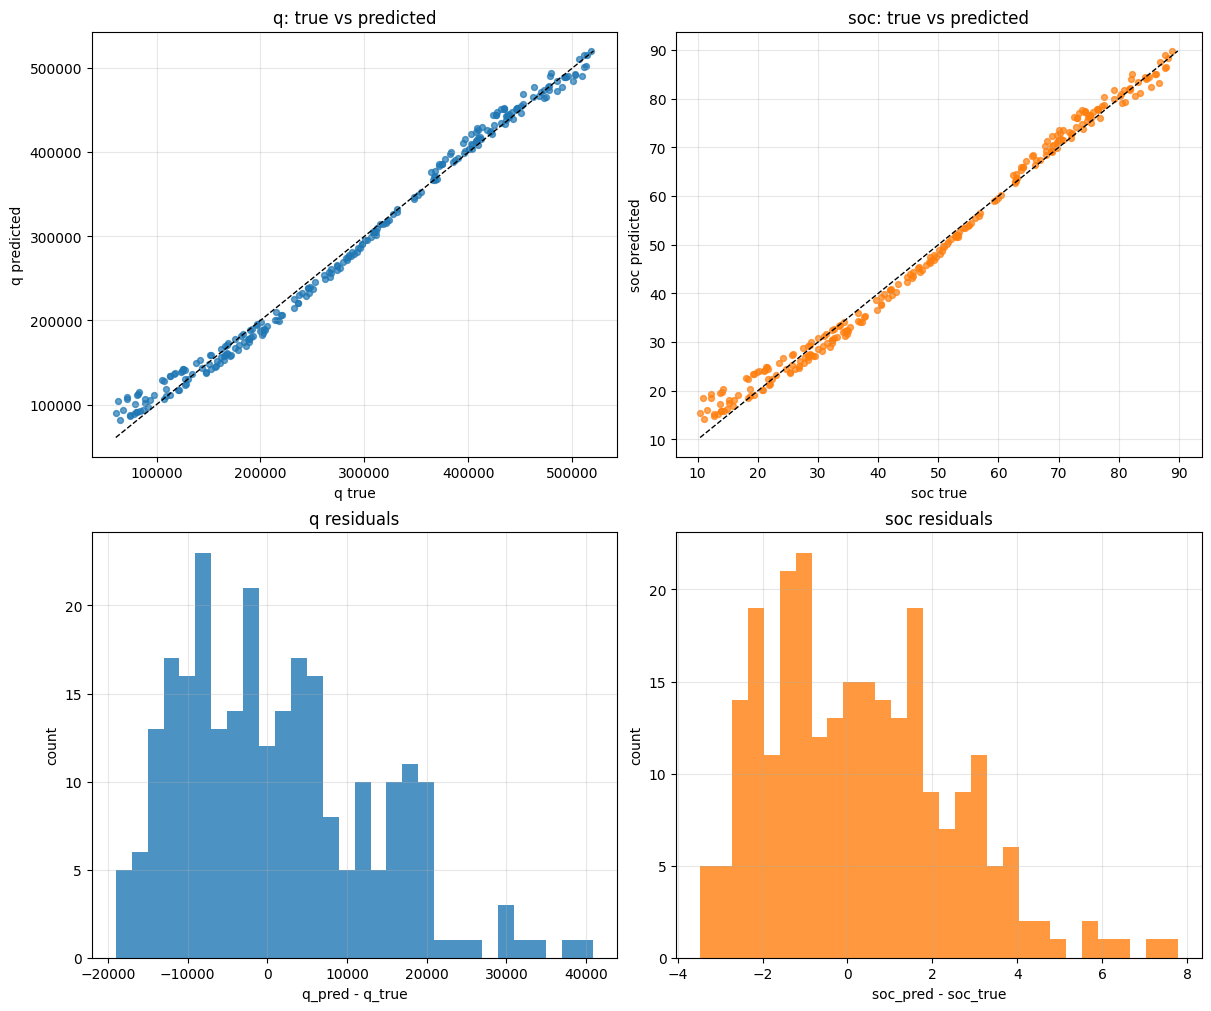

In [34]:
# Verification plots and metrics on random OP1-OP6 samples.
import matplotlib.pyplot as plt

n_verify = 256

sampled_verify = sample(n_verify)
headers_verify = [str(h) for h in sampled_verify[0].tolist()]
values_verify = np.asarray(sampled_verify[1:], dtype=float)

op_idx = headers_verify.index("op_id")
q_idx = headers_verify.index("q")
soc_idx = headers_verify.index("soc")
feature_cols = scaler["feature_cols"]

op_ids = values_verify[:, op_idx].astype(int)
x_verify_np = values_verify[:, feature_cols]
y_verify_true = values_verify[:, [q_idx, soc_idx]]
x_verify_np_norm = (x_verify_np - scaler["x_mean"]) / scaler["x_std"]

model.eval()
with torch.no_grad():
    x_verify = torch.tensor(x_verify_np_norm, dtype=torch.float32, device=device)
    y_verify_pred = _denorm_y(model(x_verify), scaler).cpu().numpy()

q_true = y_verify_true[:, 0]
soc_true = y_verify_true[:, 1]
q_pred = y_verify_pred[:, 0]
soc_pred = y_verify_pred[:, 1]

q_abs_err = np.abs(q_pred - q_true)
soc_abs_err = np.abs(soc_pred - soc_true)
q_rmse = float(np.sqrt(np.mean((q_pred - q_true) ** 2)))
soc_rmse = float(np.sqrt(np.mean((soc_pred - soc_true) ** 2)))

print(f"Verification sample count: {n_verify}")
print(f"Overall q   MAE : {np.mean(q_abs_err):.6f}")
print(f"Overall q   RMSE: {q_rmse:.6f}")
print(f"Overall soc MAE : {np.mean(soc_abs_err):.6f}")
print(f"Overall soc RMSE: {soc_rmse:.6f}")

print("\nPer-OP MAE summary:")
print(" OP |      q_mae |    soc_mae | count")
print("----+------------+------------+------")
for op_id in sorted(np.unique(op_ids)):
    mask = op_ids == op_id
    print(
        f" {op_id:>2d} | {np.mean(q_abs_err[mask]):10.6f} | {np.mean(soc_abs_err[mask]):10.6f} | {np.sum(mask):5d}"
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

q_min = min(float(np.min(q_true)), float(np.min(q_pred)))
q_max = max(float(np.max(q_true)), float(np.max(q_pred)))
soc_min = min(float(np.min(soc_true)), float(np.min(soc_pred)))
soc_max = max(float(np.max(soc_true)), float(np.max(soc_pred)))

axes[0, 0].scatter(q_true, q_pred, s=18, alpha=0.7)
axes[0, 0].plot([q_min, q_max], [q_min, q_max], "k--", linewidth=1)
axes[0, 0].set_title("q: true vs predicted")
axes[0, 0].set_xlabel("q true")
axes[0, 0].set_ylabel("q predicted")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(soc_true, soc_pred, s=18, alpha=0.7, color="tab:orange")
axes[0, 1].plot([soc_min, soc_max], [soc_min, soc_max], "k--", linewidth=1)
axes[0, 1].set_title("soc: true vs predicted")
axes[0, 1].set_xlabel("soc true")
axes[0, 1].set_ylabel("soc predicted")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(q_pred - q_true, bins=30, color="tab:blue", alpha=0.8)
axes[1, 0].set_title("q residuals")
axes[1, 0].set_xlabel("q_pred - q_true")
axes[1, 0].set_ylabel("count")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(soc_pred - soc_true, bins=30, color="tab:orange", alpha=0.8)
axes[1, 1].set_title("soc residuals")
axes[1, 1].set_xlabel("soc_pred - soc_true")
axes[1, 1].set_ylabel("count")
axes[1, 1].grid(True, alpha=0.3)

plt.show()

Holdout evaluation uses OP7 (train is OP1..OP6).
OP7 bc_v test samples: 14193
OP7 bc_v MAE : 0.035664
OP7 bc_v RMSE: 0.042356
OP7 bc_v MAPE: 0.897%

First 10 OP7 bc_v samples (true vs pred):
 idx |       time |   bc_v_true |   bc_v_pred
-----+------------+-------------+-------------
   0 |      0.100 |    3.503408 |    3.766094
   1 |      0.200 |    3.586039 |    3.766094
   2 |      0.300 |    3.650530 |    3.766094
   3 |      0.400 |    3.683999 |    3.766094
   4 |      0.500 |    3.706213 |    3.766094
   5 |      0.600 |    3.719493 |    3.766094
   6 |      0.700 |    3.727058 |    3.766094
   7 |      0.800 |    3.732324 |    3.766094
   8 |      0.900 |    3.736215 |    3.766094
   9 |      1.000 |    3.739117 |    3.766094

OP7 electrical residual (pred) RMS: 0.659433


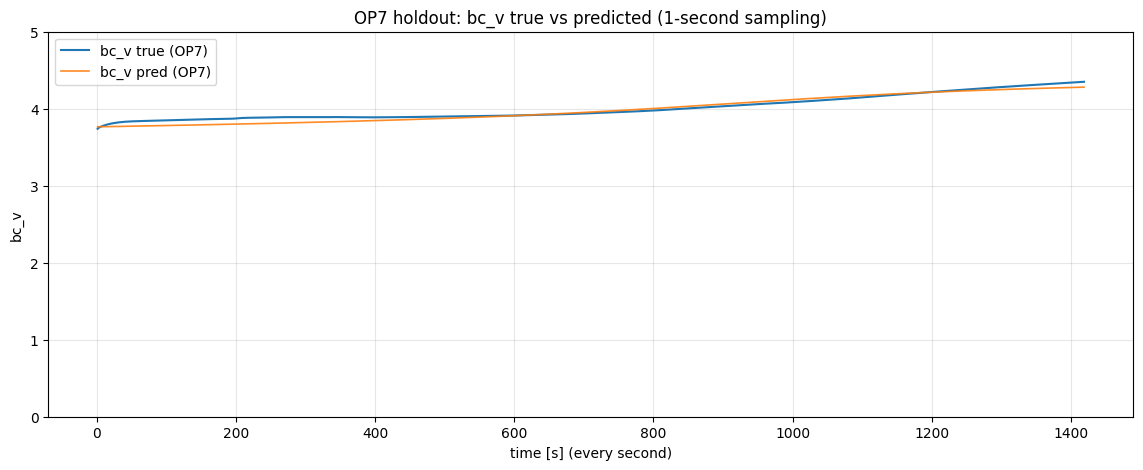

In [35]:
# OP7 holdout test focused on bc_v prediction + per-second true-vs-pred plot.
import matplotlib.pyplot as plt

def _load_single_row_csv(file_path: Path) -> tuple[list[str], np.ndarray]:
    with file_path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        headers = next(reader)
    data = np.genfromtxt(file_path, delimiter=",", skip_header=1, dtype=float)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    vals = np.asarray(data, dtype=float).reshape(-1)
    return headers, vals

op_test = TEST_OP_ID
print(f"Holdout evaluation uses OP{op_test} (train is OP1..OP6).")

# Load OP7 static inputs and fluids directly from CSVs.
op7_input_file = get_op_file(op_test, f"OP{op_test}_Input Signale.csv")
op7_fluid_file = get_op_file(op_test, f"OP{op_test}_Fluidstoffwerte.csv")
_, op7_input_vals = _load_single_row_csv(op7_input_file)
_, op7_fluid_vals = _load_single_row_csv(op7_fluid_file)

# Build feature matrix for each OP7 time step in the same order as training:
# [time, input signals..., fluid values...]
t7 = T_by_op[op_test]
x7_phys = np.column_stack([
    t7.reshape(-1, 1),
    np.tile(op7_input_vals.reshape(1, -1), (t7.shape[0], 1)),
    np.tile(op7_fluid_vals.reshape(1, -1), (t7.shape[0], 1)),
])

# Preprocess with the same clipping used in training.
x7_phys = np.clip(x7_phys, scaler["x_low"], scaler["x_high"])

# Normalize and predict.
x7_norm = (x7_phys - scaler["x_mean"]) / scaler["x_std"]
x7_norm = np.clip(x7_norm, -6.0, 6.0)
x7_tensor = torch.tensor(x7_norm, dtype=torch.float32, device=device)
model.eval()
with torch.no_grad():
    y7_pred_norm = model(x7_tensor)
    y7_pred = _denorm_y(y7_pred_norm, scaler).cpu().numpy()

# Ground truth targets from FMU for OP7.
y7_true = target_by_op[op_test][:, :len(scaler["target_names"])]

idx_v = scaler["target_pos"]["bc_v"]
idx_ocv = scaler["target_pos"]["bc_ocv"]
idx_vloss = scaler["target_pos"]["pe_v_loss"]

bc_v_true = y7_true[:, idx_v]
bc_v_pred = y7_pred[:, idx_v]

bc_v_mae = float(np.mean(np.abs(bc_v_pred - bc_v_true)))
bc_v_rmse = float(np.sqrt(np.mean((bc_v_pred - bc_v_true) ** 2)))
bc_v_mape = float(np.mean(np.abs((bc_v_pred - bc_v_true) / np.maximum(np.abs(bc_v_true), 1e-6))) * 100.0)

print(f"OP7 bc_v test samples: {t7.shape[0]}")
print(f"OP7 bc_v MAE : {bc_v_mae:.6f}")
print(f"OP7 bc_v RMSE: {bc_v_rmse:.6f}")
print(f"OP7 bc_v MAPE: {bc_v_mape:.3f}%")

print("\nFirst 10 OP7 bc_v samples (true vs pred):")
print(" idx |       time |   bc_v_true |   bc_v_pred")
print("-----+------------+-------------+-------------")
for i in range(min(10, t7.shape[0])):
    print(f"{i:4d} | {t7[i]:10.3f} | {bc_v_true[i]:11.6f} | {bc_v_pred[i]:11.6f}")

# Electrical consistency check (prediction-side).
# pe_v_loss ?= I * (bc_v - bc_ocv)
current_pos = scaler["current_pos_in_x"]
current7 = x7_phys[:, current_pos]
vloss_rhs_pred = current7 * (y7_pred[:, idx_v] - y7_pred[:, idx_ocv])
vloss_residual = y7_pred[:, idx_vloss] - vloss_rhs_pred
print(f"\nOP7 electrical residual (pred) RMS: {float(np.sqrt(np.mean(vloss_residual ** 2))):.6f}")

# Plot at every second: bc_v on y-axis, time in seconds on x-axis.
sec_start = int(np.ceil(float(np.min(t7))))
sec_end = int(np.floor(float(np.max(t7))))
seconds = np.arange(sec_start, sec_end + 1, 1, dtype=float)

if seconds.size > 0:
    pos = np.searchsorted(t7, seconds, side="left")
    pos = np.clip(pos, 1, t7.shape[0] - 1)
    left = pos - 1
    right = pos
    choose_right = np.abs(t7[right] - seconds) < np.abs(t7[left] - seconds)
    idx_sec = np.where(choose_right, right, left)

    bc_v_true_sec = bc_v_true[idx_sec]
    bc_v_pred_sec = bc_v_pred[idx_sec]

    plt.figure(figsize=(14, 5))
    plt.plot(seconds, bc_v_true_sec, label="bc_v true (OP7)", linewidth=1.5)
    plt.plot(seconds, bc_v_pred_sec, label="bc_v pred (OP7)", linewidth=1.2, alpha=0.9)
    plt.xlabel("time [s] (every second)")
    plt.ylabel("bc_v")
    plt.title("OP7 holdout: bc_v true vs predicted (1-second sampling)")
    plt.ylim(0, 5)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("No full-second timestamps available for plotting.")

## MLP Baseline (New Cell, Physics Loss = 0)
This section reproduces the OP7 bc_v holdout experiment with the same split and training settings, but as a pure data-driven MLP baseline by setting all physics loss weights to zero.

In [36]:
# MLP BASELINE training cell (same settings as PINN, but physics losses are forced to zero).
print(f"MLP baseline split check -> TRAIN_OP_IDS={TRAIN_OP_IDS}, TEST_OP_ID={TEST_OP_ID}")

mlp_hidden_layers = [128, 128, 128]
mlp_n_train = 1000
mlp_epochs = 800
mlp_learning_rate = 5e-4

# Keep output emphasis identical to the PINN run.
mlp_output_weights = {
    "q": 1.0,
    "soc": 1.0,
    "bc_v": 2.5,
    "bc_ocv": 1.0,
    "pe_v_loss": 1.0,
}

mlp_coulomb_efficiency = 1.0
mlp_current_sign = 1.0
mlp_grad_clip_norm = 1.0
mlp_print_every = 20

input_dim = len(scaler["feature_cols"])
output_dim = len(scaler["target_names"])

mlp_model = BatteryPINN(input_dim=input_dim, hidden_layers=mlp_hidden_layers, output_dim=output_dim).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=mlp_learning_rate)

mlp_history = train_pinn(
    model=mlp_model,
    sample_fn=sample,
    scaler=scaler,
    optimizer=mlp_optimizer,
    n_train=mlp_n_train,
    epochs=mlp_epochs,
    lambda_physics=0.0,
    lambda_soc_physics=0.0,
    lambda_power_physics=0.0,
    output_weights=mlp_output_weights,
    coulomb_efficiency=mlp_coulomb_efficiency,
    current_sign=mlp_current_sign,
    grad_clip_norm=mlp_grad_clip_norm,
    print_every=mlp_print_every,
)

print("MLP baseline training finished (physics losses are zero).")

MLP baseline split check -> TRAIN_OP_IDS=(1, 2, 3, 4, 5, 6), TEST_OP_ID=7
Epoch     1/800 (  0.12%) | total=6.604312e+00 | data=6.604312e+00 | physics=0.000000e+00 | phys_soc=1.252e-06 | phys_power=6.944e+02 | q=1.003e+00 | soc=9.945e-01 | bc_v=1.049e+00 | bc_ocv=9.389e-01 | pe_v_loss=1.046e+00
Epoch    20/800 (  2.50%) | total=1.691763e+00 | data=1.691763e+00 | physics=0.000000e+00 | phys_soc=2.060e-06 | phys_power=1.154e+03 | q=2.764e-01 | soc=3.114e-01 | bc_v=6.964e-02 | bc_ocv=3.800e-01 | pe_v_loss=5.498e-01
Epoch    40/800 (  5.00%) | total=7.369587e-01 | data=7.369587e-01 | physics=0.000000e+00 | phys_soc=4.943e-06 | phys_power=3.637e+02 | q=1.253e-02 | soc=1.653e-02 | bc_v=6.888e-02 | bc_ocv=5.777e-02 | pe_v_loss=4.779e-01
Epoch    60/800 (  7.50%) | total=5.433416e-01 | data=5.433416e-01 | physics=0.000000e+00 | phys_soc=4.683e-06 | phys_power=1.572e+02 | q=7.340e-03 | soc=8.231e-03 | bc_v=4.093e-02 | bc_ocv=3.292e-02 | pe_v_loss=3.925e-01
Epoch    80/800 ( 10.00%) | total=4.62

MLP baseline holdout evaluation uses OP7 (train is OP1..OP6).
MLP OP7 bc_v test samples: 14193
MLP OP7 bc_v MAE : 0.019339
MLP OP7 bc_v RMSE: 0.023236
MLP OP7 bc_v MAPE: 0.492%

First 10 OP7 bc_v samples (true vs pred):
 idx |       time |   bc_v_true |   bc_v_pred
-----+------------+-------------+-------------
   0 |      0.100 |    3.503408 |    3.761269
   1 |      0.200 |    3.586039 |    3.761269
   2 |      0.300 |    3.650530 |    3.761269
   3 |      0.400 |    3.683999 |    3.761269
   4 |      0.500 |    3.706213 |    3.761269
   5 |      0.600 |    3.719493 |    3.761269
   6 |      0.700 |    3.727058 |    3.761269
   7 |      0.800 |    3.732324 |    3.761269
   8 |      0.900 |    3.736215 |    3.761269
   9 |      1.000 |    3.739117 |    3.761269

MLP OP7 electrical residual (pred) RMS: 13.566529


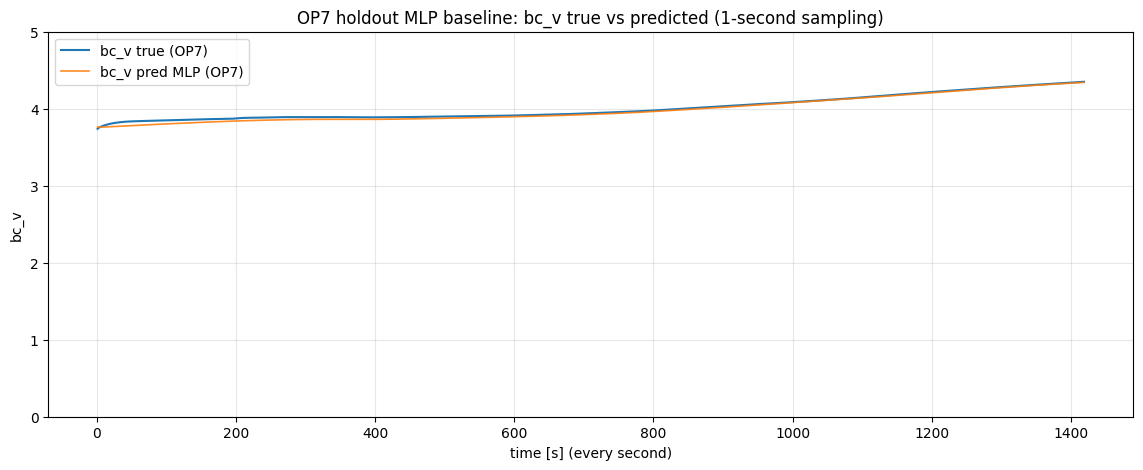

In [37]:
# MLP BASELINE OP7 holdout test focused on bc_v prediction + per-second true-vs-pred plot.
import matplotlib.pyplot as plt

# Reuse helper if available; define if missing.
if "_load_single_row_csv" not in globals():
    def _load_single_row_csv(file_path: Path) -> tuple[list[str], np.ndarray]:
        with file_path.open("r", encoding="utf-8-sig", newline="") as f:
            reader = csv.reader(f)
            headers = next(reader)
        data = np.genfromtxt(file_path, delimiter=",", skip_header=1, dtype=float)
        if data.ndim == 1:
            data = data.reshape(1, -1)
        vals = np.asarray(data, dtype=float).reshape(-1)
        return headers, vals

op_test = TEST_OP_ID
print(f"MLP baseline holdout evaluation uses OP{op_test} (train is OP1..OP6).")

# Load OP7 static inputs and fluids directly from CSVs.
op7_input_file = get_op_file(op_test, f"OP{op_test}_Input Signale.csv")
op7_fluid_file = get_op_file(op_test, f"OP{op_test}_Fluidstoffwerte.csv")
_, op7_input_vals = _load_single_row_csv(op7_input_file)
_, op7_fluid_vals = _load_single_row_csv(op7_fluid_file)

# Build feature matrix for each OP7 time step in the same order as training:
# [time, input signals..., fluid values...]
t7 = T_by_op[op_test]
x7_phys = np.column_stack([
    t7.reshape(-1, 1),
    np.tile(op7_input_vals.reshape(1, -1), (t7.shape[0], 1)),
    np.tile(op7_fluid_vals.reshape(1, -1), (t7.shape[0], 1)),
])

# Preprocess with the same clipping used in training.
x7_phys = np.clip(x7_phys, scaler["x_low"], scaler["x_high"])

# Normalize and predict with MLP baseline model.
x7_norm = (x7_phys - scaler["x_mean"]) / scaler["x_std"]
x7_norm = np.clip(x7_norm, -6.0, 6.0)
x7_tensor = torch.tensor(x7_norm, dtype=torch.float32, device=device)
mlp_model.eval()
with torch.no_grad():
    mlp_y7_pred_norm = mlp_model(x7_tensor)
    mlp_y7_pred = _denorm_y(mlp_y7_pred_norm, scaler).cpu().numpy()

# Ground truth targets from FMU for OP7.
y7_true = target_by_op[op_test][:, :len(scaler["target_names"])]

idx_v = scaler["target_pos"]["bc_v"]
idx_ocv = scaler["target_pos"]["bc_ocv"]
idx_vloss = scaler["target_pos"]["pe_v_loss"]

mlp_bc_v_true = y7_true[:, idx_v]
mlp_bc_v_pred = mlp_y7_pred[:, idx_v]

mlp_bc_v_mae = float(np.mean(np.abs(mlp_bc_v_pred - mlp_bc_v_true)))
mlp_bc_v_rmse = float(np.sqrt(np.mean((mlp_bc_v_pred - mlp_bc_v_true) ** 2)))
mlp_bc_v_mape = float(np.mean(np.abs((mlp_bc_v_pred - mlp_bc_v_true) / np.maximum(np.abs(mlp_bc_v_true), 1e-6))) * 100.0)

print(f"MLP OP7 bc_v test samples: {t7.shape[0]}")
print(f"MLP OP7 bc_v MAE : {mlp_bc_v_mae:.6f}")
print(f"MLP OP7 bc_v RMSE: {mlp_bc_v_rmse:.6f}")
print(f"MLP OP7 bc_v MAPE: {mlp_bc_v_mape:.3f}%")

print("\nFirst 10 OP7 bc_v samples (true vs pred):")
print(" idx |       time |   bc_v_true |   bc_v_pred")
print("-----+------------+-------------+-------------")
for i in range(min(10, t7.shape[0])):
    print(f"{i:4d} | {t7[i]:10.3f} | {mlp_bc_v_true[i]:11.6f} | {mlp_bc_v_pred[i]:11.6f}")

# Electrical consistency check (prediction-side).
# pe_v_loss ?= I * (bc_v - bc_ocv)
current_pos = scaler["current_pos_in_x"]
current7 = x7_phys[:, current_pos]
mlp_vloss_rhs_pred = current7 * (mlp_y7_pred[:, idx_v] - mlp_y7_pred[:, idx_ocv])
mlp_vloss_residual = mlp_y7_pred[:, idx_vloss] - mlp_vloss_rhs_pred
print(f"\nMLP OP7 electrical residual (pred) RMS: {float(np.sqrt(np.mean(mlp_vloss_residual ** 2))):.6f}")

# Plot at every second: bc_v on y-axis, time in seconds on x-axis.
sec_start = int(np.ceil(float(np.min(t7))))
sec_end = int(np.floor(float(np.max(t7))))
seconds = np.arange(sec_start, sec_end + 1, 1, dtype=float)

if seconds.size > 0:
    pos = np.searchsorted(t7, seconds, side="left")
    pos = np.clip(pos, 1, t7.shape[0] - 1)
    left = pos - 1
    right = pos
    choose_right = np.abs(t7[right] - seconds) < np.abs(t7[left] - seconds)
    idx_sec = np.where(choose_right, right, left)

    mlp_bc_v_true_sec = mlp_bc_v_true[idx_sec]
    mlp_bc_v_pred_sec = mlp_bc_v_pred[idx_sec]

    plt.figure(figsize=(14, 5))
    plt.plot(seconds, mlp_bc_v_true_sec, label="bc_v true (OP7)", linewidth=1.5)
    plt.plot(seconds, mlp_bc_v_pred_sec, label="bc_v pred MLP (OP7)", linewidth=1.2, alpha=0.9)
    plt.xlabel("time [s] (every second)")
    plt.ylabel("bc_v")
    plt.title("OP7 holdout MLP baseline: bc_v true vs predicted (1-second sampling)")
    plt.ylim(0, 5)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("No full-second timestamps available for plotting.")